# Class 4 - Tabular Data

Today, we move from NumPy arrays to the analysis of actual tabular data (time-series from Future Forests Hartheim), before visualizing it.

Goals:
- use Pandas to analyze time-series tabular data (filter, reduce over time, summarise),
- make a first line plot with Matplotlib.


## 1. From NumPy arrays to Pandas tables

All the exercises we have seen so far use only a few data points, so one might think that using coding tools to solve them is unnecessarily complicated. 

However, imagine that instead of 20 values, you had thousands, hundreds of thousands, or even millions of data points. In such cases, these coding tools become extremely useful, and vectorization can significantly reduce the computational time required for the calculations.

Now we are finally going to move from these dummy exercises and datasets to real-world data. First, we will use the Future Forests Hartheim climate station from: 

`../processed_data/26030350_hourly.csv` # TODO: change here?

Note: we are not working directly with the raw data file from but a post-processed cleaned version with hourly data to be easier to work with.

In addition, we are going to use the library `pandas` instead of `NumPy` because `pandas` provides convenient and more powerfull tools for working with structured, time-series datasets, such as selecting columns, filtering data, handling missing values, and working with timestamps.


In [1]:
import pandas as pd


### i. Loading a CSV with `pd.read_csv(...)`

`pd.read_csv(...)` reads a CSV file and returns a `DataFrame`, the central object in Pandas. A `DataFrame` is a table where each column can hold a different type (numbers, strings, dates…) and every row shares the same index. You can think of it as a spreadsheet inside Python.

By default, date/time columns are read as plain text. The argument `parse_dates=['utc_time']` tells Pandas to convert that column into proper datetime objects, which lets us later filter by date ranges and resample in time.


In [2]:
HartheimRaw = pd.read_csv('../processed_data/26030350_hourly.csv', parse_dates=['utc_time'])
HartheimRaw = HartheimRaw.set_index('utc_time')
print(type(HartheimRaw))
print(HartheimRaw.shape)
print(HartheimRaw.columns)

<class 'pandas.core.frame.DataFrame'>
(330, 21)
Index(['logger_id', 'battery_v', 'signal_quality', 'info_byte', 'packet_count',
       'gust_speed', 'wind_direction', 'average_wind_speed', 'precipitation',
       'par', 'temperature_2m', 'humidity_2m', 'temperature_ground',
       'humidity_ground', 'distance', 'permitivity_0_2', 'vwc_0_2',
       'soil_temperature_0_2', 'permitivity_0_6', 'vwc_0_6',
       'soil_temperature_0_6'],
      dtype='object')


In [3]:
print(HartheimRaw)

                     logger_id  battery_v  signal_quality  info_byte  \
utc_time                                                               
2026-07-20 15:00:00   26030350  13.330000       12.400000  20.000000   
2026-07-20 16:00:00   26030350  13.300000       29.333333  20.083333   
2026-07-20 17:00:00   26030350  13.258333       32.666667  20.083333   
2026-07-20 18:00:00   26030350  13.283333       32.333333  20.083333   
2026-07-20 19:00:00   26030350  13.325000       33.333333  20.083333   
...                        ...        ...             ...        ...   
2026-08-03 04:00:00   26030350  13.300000       28.833333  20.083333   
2026-08-03 05:00:00   26030350  13.250000       28.833333  20.083333   
2026-08-03 06:00:00   26030350  13.227273       28.090909  20.090909   
2026-08-03 07:00:00   26030350  13.233333       27.333333  20.083333   
2026-08-03 08:00:00   26030350  13.233333       27.000000  20.000000   

                     packet_count  gust_speed  wind_direction  

As you can see we moved from data with less than 10 data points to a dataset with 330*22 = 7.260 entries.

### ii. Basic Pandas operations

#### a. Column selection

A DataFrame often has more columns than you need. You can select a subset by passing a list of column names.


In [4]:
VariablesToKeep = ['temperature_2m', 'humidity_2m', 'temperature_ground', 'precipitation']
HartheimData = HartheimRaw[VariablesToKeep]
print(HartheimData.columns)

Index(['temperature_2m', 'humidity_2m', 'temperature_ground', 'precipitation'], dtype='object')


#### b. Indexing and slicing

In `NumPy`, indexing is almost always by **position**: `Array[0]` is the first element, and `Array[1:5]` selects positions 1 to 4 (stop excluded).

In `pandas`, there are two ways to do indexing and slicing,

- by **position** (row/column numbers) with `.iloc[row_index, column_index]` (similar to `Numpy`):


In [5]:
print(HartheimData.iloc[0, 1])
print(HartheimData.iloc[0:3, 1:3])

36.10277777777778
                     humidity_2m  temperature_ground
utc_time                                            
2026-07-20 15:00:00    36.102778           27.135000
2026-07-20 16:00:00    36.362417           26.831250
2026-07-20 17:00:00    38.146333           26.585917



- or by **label** (names / dates) with `.loc[row_names, column_names]`. But before being able to use label, we need labels for our rows. `.set_index('utc_time')` moves the time column from a regular column to the row index. Once the index is a datetime, you can slice by date strings with `.loc['start':'end']` (both ends included). This is much more readable than writing manual comparisons.


In [6]:
print(HartheimData.loc['2026-07-24':'2026-07-26', ['temperature_2m', 'temperature_ground']])

                     temperature_2m  temperature_ground
utc_time                                               
2026-07-24 00:00:00       11.073583           11.128500
2026-07-24 01:00:00       10.512500           10.604167
2026-07-24 02:00:00        9.748333            9.848333
2026-07-24 03:00:00        9.067750            9.128583
2026-07-24 04:00:00        8.533692            8.623154
...                             ...                 ...
2026-07-26 19:00:00       25.837083           25.266167
2026-07-26 20:00:00       24.171333           23.594167
2026-07-26 21:00:00       22.694750           22.340750
2026-07-26 22:00:00       22.072417           21.671333
2026-07-26 23:00:00       21.837250           21.247167

[72 rows x 2 columns]


⚠️ Important difference: with `.loc`, a slice like `'2026-07-24':'2026-07-26'` is **inclusive on both ends**. In `NumPy`, the stop index is excluded.

#### c. Creating a new column:

You can create a new column by assigning the result of an operation between existing columns. Here we compute the vertical temperature gradient (2 m minus ground). The operation is vectorised, just like in NumPy.


In [7]:
HartheimData['temp_gradient_2m_minus_ground'] = HartheimData['temperature_2m'] - HartheimData['temperature_ground']
print(HartheimData[['temperature_2m', 'temperature_ground', 'temp_gradient_2m_minus_ground']].head())

                     temperature_2m  temperature_ground  \
utc_time                                                  
2026-07-20 15:00:00       26.820333           27.135000   
2026-07-20 16:00:00       26.664333           26.831250   
2026-07-20 17:00:00       26.656167           26.585917   
2026-07-20 18:00:00       26.638417           26.497000   
2026-07-20 19:00:00       26.585833           26.419833   

                     temp_gradient_2m_minus_ground  
utc_time                                            
2026-07-20 15:00:00                      -0.314667  
2026-07-20 16:00:00                      -0.166917  
2026-07-20 17:00:00                       0.070250  
2026-07-20 18:00:00                       0.141417  
2026-07-20 19:00:00                       0.166000  


/var/folders/77/k3yb4m_j4dv_gjr8_zyv1clc000fvt/T/ipykernel_14881/2299385075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HartheimData['temp_gradient_2m_minus_ground'] = HartheimData['temperature_2m'] - HartheimData['temperature_ground']


#### d. Summary statistics

`.describe()` gives you count, mean, standard deviation, min, max, and quartiles in one call. Pandas skips `NaN` values automatically, so you get correct statistics even when some measurements are missing.


In [8]:
print(HartheimData[['temperature_2m', 'humidity_2m', 'precipitation']].describe())

       temperature_2m  humidity_2m  precipitation
count      330.000000   330.000000     330.000000
mean        23.110329    61.535074       0.004581
std          6.734394    23.067746       0.045724
min          8.533692    17.582917       0.000000
25%         18.355062    41.933250       0.000000
50%         23.457179    57.750057       0.000000
75%         28.015835    83.719167       0.000000
max         40.331333    99.990000       0.663717


### iii. Vectorisation operations with Pandas

In NumPy we used vectorised formulas, we can do exactly the same on Pandas columns.

In [9]:
HartheimData['rh_deficit_pct'] = 100 - HartheimData['humidity_2m']
print(HartheimData['rh_deficit_pct'].head())

utc_time
2026-07-20 15:00:00    63.897222
2026-07-20 16:00:00    63.637583
2026-07-20 17:00:00    61.853667
2026-07-20 18:00:00    60.140667
2026-07-20 19:00:00    58.861583
Name: rh_deficit_pct, dtype: float64


/var/folders/77/k3yb4m_j4dv_gjr8_zyv1clc000fvt/T/ipykernel_14881/4290458131.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HartheimData['rh_deficit_pct'] = 100 - HartheimData['humidity_2m']


In [10]:
MeanHumidity = HartheimData['humidity_2m'].mean()
MeanRhDeficit = HartheimData['rh_deficit_pct'].mean()
print(f'Mean 2m humidity: {MeanHumidity:.1f} %')
print(f'Mean RH deficit: {MeanRhDeficit:.1f} %')

Mean 2m humidity: 61.5 %
Mean RH deficit: 38.5 %


## Exercise A

This exercise is a copy of **Class 3 Exercise A**, except that you must use the Hartheim DataFrame and vectorisation this time.

Your American cousin, an avid gardener, comes to visit you and doesn't understand degrees Celsius. The Hartheim station records air temperature at 2 m in °C, but your cousin wants to read it in °F.

Tasks:
1. Add a new column `temperature_2m_f` with the 2 m air temperature converted to Fahrenheit
2. Print the mean 2 m temperature in both °C and °F.

In [11]:
HartheimData['temperature_2m_f'] = HartheimData['temperature_2m'] * 9 / 5 + 32
MeanC = HartheimData['temperature_2m'].mean()
MeanF = HartheimData['temperature_2m_f'].mean()
print(f'Mean 2m temperature: {MeanC:.2f} °C')
print(f'Mean 2m temperature: {MeanF:.2f} °F')

Mean 2m temperature: 23.11 °C
Mean 2m temperature: 73.60 °F


/var/folders/77/k3yb4m_j4dv_gjr8_zyv1clc000fvt/T/ipykernel_14881/4286967795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HartheimData['temperature_2m_f'] = HartheimData['temperature_2m'] * 9 / 5 + 32


### iv. Filtering rows

Filtering keeps only the rows that match a condition. In Pandas this uses a **Boolean mask**: a column of `True`/`False` values, one per row. You write the condition, then put the mask inside `[]`.

In [12]:
HotTemp = HartheimData[HartheimData['temperature_2m'] > 38]
print('Hot temperatures (>38°C):', HotTemp['temperature_2m'])

Hot temperatures (>38°C): utc_time
2026-07-29 14:00:00    38.368500
2026-07-29 15:00:00    38.014000
2026-07-30 11:00:00    39.497231
2026-07-30 12:00:00    40.331333
Name: temperature_2m, dtype: float64


Try to print the **number of hours** with cold temperatures (colder than 10°C)

In [13]:
print(len(HartheimData[HartheimData['temperature_2m'] < 10]))

8


In [14]:
WarmHumid = HartheimData[(HartheimData['temperature_2m'] > 25) & (HartheimData['humidity_2m'] > 60)]
print('Warm and humid hours:', len(WarmHumid))

Warm and humid hours: 5


In [15]:
LateJulyMask = HartheimData[(HartheimData.index >= '2026-07-24') & (HartheimData.index <= '2026-07-26')]
print('Rows with index mask:', len(LateJulyMask))

Rows with index mask: 49


#### a. Getting row labels with `.index`

Every DataFrame has an **index**: the label for each row. After `set_index('utc_time')`, the index holds the UTC timestamps.

- `HartheimData.index` — all row labels (here: UTC times)
- `df.index[mask]` — keep only the labels where the Boolean mask is `True`

This is useful when you want the **times** that match a condition, not the full rows.

In [16]:
WarmHumidMask = (HartheimData['temperature_2m'] > 25) & (HartheimData['humidity_2m'] > 60)
print('UTC times warm and humid:')
print(HartheimData.index[WarmHumidMask])

UTC times warm and humid:
DatetimeIndex(['2026-07-31 07:00:00', '2026-08-01 09:00:00',
               '2026-08-01 10:00:00', '2026-08-02 09:00:00',
               '2026-08-02 19:00:00'],
              dtype='datetime64[ns]', name='utc_time', freq=None)


### v. Changing time resolution (`resample`)

Sometimes we want to change the time resolution of a series. For example, roll hourly measurements up to daily values. **Resampling** groups rows into coarser time bins (e.g. days) and then applies an aggregation such as mean or sum.

Because the index is already a datetime, you can write:

- `.resample('D').mean()` — daily average (good for temperature, humidity)
- `.resample('D').sum()` — daily total (good for precipitation)

`'D'` means calendar day. Other common frequencies: `'h'` (hour), `'W'` (week), `'ME'` (month end) or `'YE'` (year end).

In [17]:
DailyMean = HartheimData[['temperature_2m', 'humidity_2m']].resample('D').mean()
print('Before:')
print(HartheimData)
print('After:')
print(DailyMean)

Before:
                     temperature_2m  humidity_2m  temperature_ground  \
utc_time                                                               
2026-07-20 15:00:00       26.820333    36.102778           27.135000   
2026-07-20 16:00:00       26.664333    36.362417           26.831250   
2026-07-20 17:00:00       26.656167    38.146333           26.585917   
2026-07-20 18:00:00       26.638417    39.859333           26.497000   
2026-07-20 19:00:00       26.585833    41.138417           26.419833   
...                             ...          ...                 ...   
2026-08-03 04:00:00       19.809583    89.150000           19.638750   
2026-08-03 05:00:00       20.084333    89.403333           19.885417   
2026-08-03 06:00:00       22.181182    77.956000           21.640545   
2026-08-03 07:00:00       25.865417    57.769750           25.454583   
2026-08-03 08:00:00       27.163667    59.663333           26.980667   

                     precipitation  temp_gradient_2m_mi

In [18]:
DailyPrecip = HartheimData[['precipitation']].resample('D').sum()
print('\nDaily precipitation totals (mm):')
print(DailyPrecip)


Daily precipitation totals (mm):
            precipitation
utc_time                 
2026-07-20       0.368732
2026-07-21       0.110619
2026-07-22       0.000000
2026-07-23       0.000000
2026-07-24       0.000000
2026-07-25       0.000000
2026-07-26       0.000000
2026-07-27       0.000000
2026-07-28       0.000000
2026-07-29       0.000000
2026-07-30       0.000000
2026-07-31       0.331858
2026-08-01       0.700590
2026-08-02       0.000000
2026-08-03       0.000000


Try to print the weekly mean temperature and total precipitation

In [19]:
subset = HartheimData.loc['2026-07-20':'2026-08-02']
print(subset[['temperature_2m']].resample('W').mean())
print(subset[['precipitation']].resample('W').sum())

            temperature_2m
utc_time                  
2026-07-26       21.537565
2026-08-02       24.632736
            precipitation
utc_time                 
2026-07-26       0.479351
2026-08-02       1.032448


## Exercise B

Root growth and soil microbial activity often depend on how warm the upper soil layers are compared with deeper layers. You are investigating whether the upper soil layer becomes substantially warmer than the deeper soil layer during warm conditions at the Hartheim station.

The logger measures soil temperature at two depths: about 0.2 m (`soil_temperature_0_2`) and about 0.6 m (`soil_temperature_0_6`).

Tasks:
1. Compute the mean and standard deviation of both soil temperature columns (`soil_temperature_0_2`, `soil_temperature_0_6`). Look up online for how to use standard deviation in `Pandas`
2. For how many hours is the 0.2 m temperature higher than the 0.6 m temperature, and for how many hours is the opposite true? 
3. Print the UTC times of all hours corresponding to the condition that occurs for the fewer number of hours.

In [20]:
SoilTemps = HartheimRaw[['soil_temperature_0_2', 'soil_temperature_0_6']]
print('Mean shallow (0.2 m):', SoilTemps['soil_temperature_0_2'].mean())
print('Std  shallow (0.2 m):', SoilTemps['soil_temperature_0_2'].std())
print('Mean deep (0.6 m):', SoilTemps['soil_temperature_0_6'].mean())
print('Std  deep (0.6 m):', SoilTemps['soil_temperature_0_6'].std())
ShallowWarmer = SoilTemps['soil_temperature_0_2'] > SoilTemps['soil_temperature_0_6']
DeepWarmer = SoilTemps['soil_temperature_0_6'] > SoilTemps['soil_temperature_0_2']
print('Hours with shallow (0.2 m) warmer than deep (0.6 m):', ShallowWarmer.sum())
print('Hours with deep (0.6 m) warmer than shallow (0.2 m):', DeepWarmer.sum())
print(SoilTemps.index[DeepWarmer])

Mean shallow (0.2 m): 19.96557652855562
Std  shallow (0.2 m): 1.7498353223953698
Mean deep (0.6 m): 18.538353819648364
Std  deep (0.6 m): 1.834708318338495
Hours with shallow (0.2 m) warmer than deep (0.6 m): 310
Hours with deep (0.6 m) warmer than shallow (0.2 m): 20
DatetimeIndex(['2026-07-20 16:00:00', '2026-07-20 17:00:00',
               '2026-07-20 18:00:00', '2026-07-20 19:00:00',
               '2026-07-20 20:00:00', '2026-07-20 21:00:00',
               '2026-07-20 22:00:00', '2026-07-20 23:00:00',
               '2026-07-21 00:00:00', '2026-07-21 01:00:00',
               '2026-07-21 02:00:00', '2026-07-21 03:00:00',
               '2026-07-21 04:00:00', '2026-07-21 05:00:00',
               '2026-07-21 06:00:00', '2026-07-22 08:00:00',
               '2026-07-22 09:00:00', '2026-07-22 10:00:00',
               '2026-07-22 11:00:00', '2026-07-22 12:00:00'],
              dtype='datetime64[ns]', name='utc_time', freq=None)


## 2. Plotting: Matplotlib essentials

Matplotlib is the most widely used plotting library in Python. We only need a handful of functions to make a clean line graph. 


In [21]:
import matplotlib.pyplot as plt

Start with a plot type function:

- `plt.plot(x, y, label='...')`, draws a line from the x and y data. The `label` is used by the legend. 

Look on the online documentation to see all the different plot types you can make

Then you have different **optional** options to choose:
- `plt.title('...')` — sets the plot title.
- `plt.xlabel('...')` / `plt.ylabel('...')` — set the axis labels.
- `plt.grid(True)` — adds a background grid for easier reading.
- `plt.legend()` — displays a legend using the labels defined in each `plt.plot()` call.

Finally, you can display the figure with `plt.show()`.


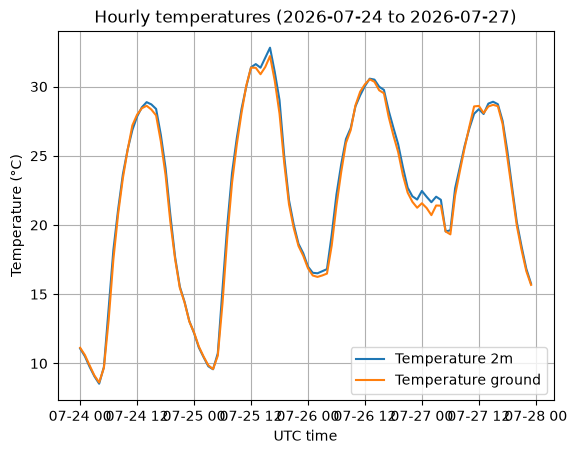

In [22]:
PlotDf = HartheimData.loc['2026-07-24':'2026-07-27']
plt.plot(PlotDf.index, PlotDf['temperature_2m'], label='Temperature 2m')
plt.plot(PlotDf.index, PlotDf['temperature_ground'], label='Temperature ground')
plt.title('Hourly temperatures (2026-07-24 to 2026-07-27)')
plt.xlabel('UTC time')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()
plt.show()

## Exercise C

After a dry period, a colleague asks whether rainy hours at Hartheim also come with higher near-surface humidity. You decide to check this visually over the full measurement period, because a simple time series plot is often the fastest way to spot co-varying weather patterns.

Using the Hartheim dataset, plot precipitation and 2 m humidity (tip: one per code cell), can you see a relationship between both?


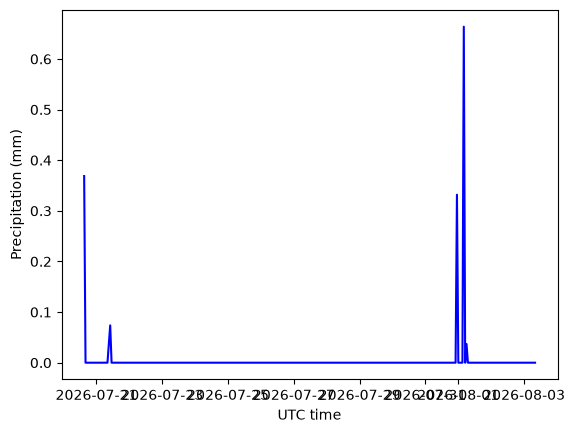

In [23]:
plt.plot(HartheimData.index, HartheimData['precipitation'], color='blue')
plt.xlabel('UTC time')
plt.ylabel('Precipitation (mm)')
plt.show()

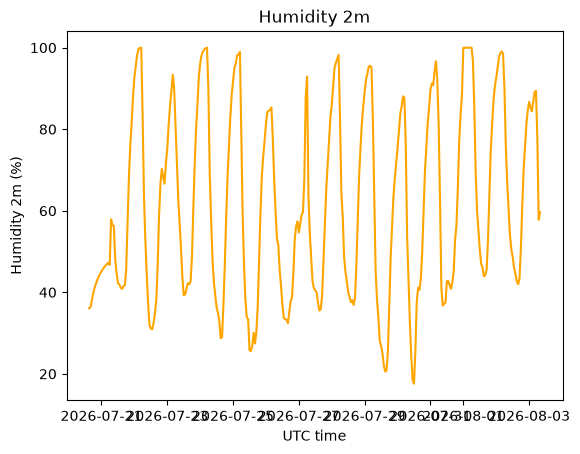

In [24]:
plt.plot(HartheimData.index, HartheimData['humidity_2m'], color='orange')
plt.title('Humidity 2m')
plt.xlabel('UTC time')
plt.ylabel('Humidity 2m (%)')
plt.show()

## Exercise D

Trees do not close their stomata because the air is hot, but because the air is *dry*. The relevant variable is the vapour pressure deficit (VPD): the difference between how much water vapour the air could hold and how much it actually holds.

You can compute VPD from the station data with the Tetens formula:

$$e_s = 0.6108 \cdot \exp\left(\frac{17.27\,T}{T + 237.3}\right) \qquad \text{VPD} = e_s \cdot \left(1 - \frac{RH}{100}\right)$$

with $T$ the air temperature in °C, $RH$ the relative humidity in %, and $e_s$ and VPD in kPa.

**Question: is the hottest day at Hartheim also the most physiologically stressful one for the trees?**

Tasks:

1. Using `temperature_2m` and `humidity_2m`, create a new column `vpd_kpa`. Do it in two vectorised steps (first `es_kpa`, then `vpd_kpa`). You will need `np.exp()`, which works directly on a Pandas column.

In [25]:
import numpy as np
VpdData = HartheimRaw.copy()
VpdData['es_kpa'] = 0.6108 * np.exp(17.27 * VpdData['temperature_2m'] / (VpdData['temperature_2m'] + 237.3))
VpdData['vpd_kpa'] = VpdData['es_kpa'] * (1 - VpdData['humidity_2m'] / 100)

2. Print the mean, minimum and maximum of `vpd_kpa`, and the UTC time at which the maximum occurs

In [26]:
print('Mean VPD: (in kPa)', VpdData['vpd_kpa'].mean())
print('Min  VPD: (in kPa)', VpdData['vpd_kpa'].min())
print('Max  VPD: (in kPa)', VpdData['vpd_kpa'].max())
print('Time of maximum VPD:', VpdData.index[VpdData['vpd_kpa'] == VpdData['vpd_kpa'].max()])

Mean VPD: (in kPa) 1.4123940336152463
Min  VPD: (in kPa) 0.00012065828230265735
Max  VPD: (in kPa) 6.186930865795295
Time of maximum VPD: DatetimeIndex(['2026-07-30 12:00:00'], dtype='datetime64[ns]', name='utc_time', freq=None)


3. A VPD above 3 kPa is often used as an indicative threshold above which stomatal conductance in temperate conifers is strongly reduced. How many hours of the record are above it? Plot VPD, and add a horizontal line at 3 kPa (look up `plt.axhline` in the Matplotlib documentation). In another cell, plot the temperature.

Number of stressful hours (VPD > 3 kPa): 25


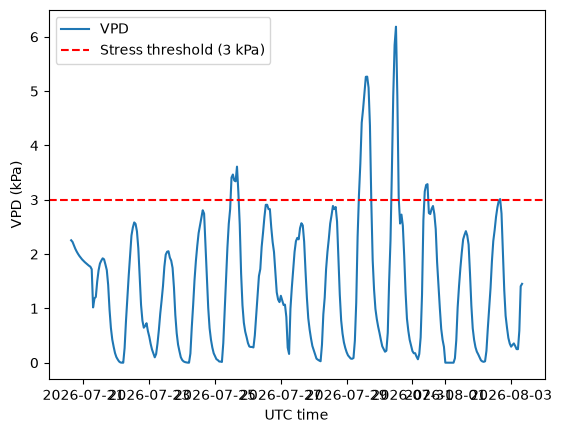

In [27]:
StressMask = VpdData['vpd_kpa'] > 3
print('Number of stressful hours (VPD > 3 kPa):', len(VpdData[StressMask]))
plt.plot(VpdData['vpd_kpa'], label='VPD')
plt.axhline(y=3, color='red', linestyle='--', label='Stress threshold (3 kPa)')
plt.xlabel('UTC time')
plt.ylabel('VPD (kPa)')
plt.legend()
plt.show()

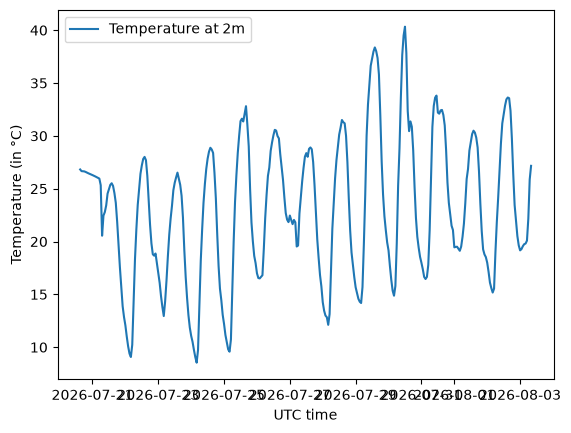

In [28]:
plt.plot(VpdData['temperature_2m'], label='Temperature at 2m')
plt.xlabel('UTC time')
plt.ylabel('Temperature (in °C)')
plt.legend()
plt.show()

4. Compare the two rankings: is the day with the highest mean temperature also the day with the highest maximum VPD?

In [29]:
DailyMeanTemp = VpdData[['temperature_2m']].resample('D').mean()
DailyMaxVpd = VpdData[['vpd_kpa']].resample('D').max()
MaxTemp = DailyMeanTemp['temperature_2m'].max()
MaxDailyVpd = DailyMaxVpd['vpd_kpa'].max()
print('Warmest day (mean T):', DailyMeanTemp.index[DailyMeanTemp['temperature_2m'] == MaxTemp])
print('Most stressful day (max VPD):', DailyMaxVpd.index[DailyMaxVpd['vpd_kpa'] == MaxDailyVpd])

Warmest day (mean T): DatetimeIndex(['2026-07-29'], dtype='datetime64[ns]', name='utc_time', freq='D')
Most stressful day (max VPD): DatetimeIndex(['2026-07-30'], dtype='datetime64[ns]', name='utc_time', freq='D')
